# T5-Base Fine-Tuning for AG News Headline Generation

Fine-tunes `t5-base` to generate concise headlines from AG News article descriptions, as part of the
[AG News Topic Classification and Headline Generation](../docs/Team8_Final_Report.pdf) project (Team 8, NLP course).

This notebook covers the individual contribution: fine-tuning and evaluating **T5-base**, which scored highest
among the three headline-generation models tested (DistilBART, T5-base, PEGASUS) with **ROUGE-L 76.81%** and
**BERTScore-F1 94.68%**.

**Pipeline:** load & preprocess AG News → tokenize → fine-tune T5-base (Seq2SeqTrainer) → evaluate (ROUGE-L,
BERTScore) → compare decoding strategies (greedy, temperature, top-k, top-p) → per-class breakdown.


## Setup

Install dependencies and import libraries.

In [ ]:
!pip install -q transformers datasets evaluate sentencepiece rouge-score bert-score matplotlib pandas seaborn nltk

import os, re, html, math, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize
from collections import defaultdict

from datasets import load_dataset
from transformers import (
    T5TokenizerFast,
    T5ForConditionalGeneration,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback,
    AutoConfig
)
import evaluate

# optional asset (you uploaded earlier)
ASSET_SAMPLE_PATH = "/mnt/data/3450f8ce-caa0-4740-a5cf-93622440146a.png"

## NLTK Setup & Stopwords

In [ ]:
try:
    nltk.data.find("tokenizers/punkt")
except:
    nltk.download("punkt", quiet=True)
try:
    nltk.data.find("tokenizers/punkt_tab")
except:
    nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
STOP_WORDS = set(stopwords.words("english"))

## Reproducibility & Device

In [ ]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

label_names = ["World", "Sports", "Business", "Sci/Tech"]

## Preprocessing Helpers (Pseudo-Headline Extraction)

In [ ]:
def clean_description(text):
    if text is None:
        return ""
    text = html.unescape(text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[\r\n\t]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def make_pseudo_headline(sentence, max_words=12):
    words = word_tokenize(sentence)
    clean_words = [
        w for w in words
        if w.lower() not in STOP_WORDS and w not in ",.!?;:\"'`-()[]{}"
    ]
    clean_words = clean_words[:max_words]
    dedup = []
    for w in clean_words:
        if not dedup or w.lower() != dedup[-1].lower():
            dedup.append(w)
    headline = " ".join(dedup).strip()
    return headline if headline else "News Update"

def split_title_desc(ex):
    txt = (ex.get("text") or "").strip()
    txt = html.unescape(txt)
    try:
        sents = sent_tokenize(txt)
    except:
        sents = re.split(r'(?<=[.!?])\s+', txt)
    if not sents:
        sents = [txt]
    first = sents[0]
    rest = " ".join(sents[1:]) if len(sents) > 1 else first
    ex["title"] = make_pseudo_headline(first)
    ex["description"] = clean_description(rest)
    ex["label_name"] = label_names[ex["label"]]
    return ex

print("Loading dataset and mapping...")
dataset = load_dataset("fancyzhx/ag_news")
dataset = dataset.map(split_title_desc)
print("Columns after:", dataset["train"].column_names)

## Load AG News Dataset

In [ ]:
SMALL_DEBUG = False
if SMALL_DEBUG:
    print("⚠️ DEBUG MODE: small subset")
    dataset["train"] = dataset["train"].select(range(4000))
    dataset["test"]  = dataset["test"].select(range(600))
print(f"Train: {len(dataset['train'])}, Test: {len(dataset['test'])}")

Loading dataset and mapping...
Columns after: ['text', 'label', 'title', 'description', 'label_name']
Train: 120000, Test: 7600


## Tokenizer & Preprocessing

In [ ]:
checkpoint = "t5-base"
tokenizer = T5TokenizerFast.from_pretrained(checkpoint)

max_input_length = 256
max_target_length = 32

def preprocess(batch):
    inputs = ["summarize: " + (d or "") for d in batch["description"]]
    targets = [(t or "") for t in batch["title"]]
    model_inputs = tokenizer(inputs, max_length=max_input_length,
                             truncation=True, padding="max_length")
    with tokenizer.as_target_tokenizer():
        labels = tokenizer(targets, max_length=max_target_length,
                           truncation=True, padding="max_length")
    labels_input_ids = labels["input_ids"]
    labels_input_ids = [
        [(tok if tok != tokenizer.pad_token_id else -100) for tok in seq]
        for seq in labels_input_ids
    ]
    model_inputs["labels"] = labels_input_ids
    return model_inputs

print("Tokenizing dataset (this may take a while for full dataset)...")
tokenized = dataset.map(preprocess, batched=True, remove_columns=dataset["train"].column_names)

Tokenizing dataset (this may take a while for full dataset)...


## Model & Evaluation Metrics

In [ ]:
model = T5ForConditionalGeneration.from_pretrained(checkpoint).to(device)
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

rouge = evaluate.load("rouge")
bertscore = evaluate.load("bertscore")

def safe_filter(preds, refs):
    P, R = [], []
    for p, r in zip(preds, refs):
        if p is None or r is None:
            continue
        if str(p).strip() == "" or str(r).strip() == "":
            continue
        P.append(p); R.append(r)
    return P, R

def decode_token_ids_to_text(ids):
    try:
        return tokenizer.batch_decode(ids, skip_special_tokens=True, clean_up_tokenization_spaces=True)
    except Exception:
        safe_ids = []
        pad = tokenizer.pad_token_id
        for seq in ids:
            fixed = []
            for x in seq:
                try:
                    xi = int(x)
                except:
                    xi = pad
                if xi < 0 or xi > tokenizer.vocab_size + 10000:
                    xi = pad
                fixed.append(xi)
            safe_ids.append(fixed)
        return tokenizer.batch_decode(safe_ids, skip_special_tokens=True, clean_up_tokenization_spaces=True)

# robust compute_metrics
def compute_metrics(eval_pred):
    preds, labels = eval_pred
    if isinstance(preds, tuple):
        preds = preds[0]
    preds = np.asarray(preds)
    labels = np.asarray(labels)

    # If preds are logits -> argmax
    if preds.dtype.kind == "f":
        if preds.ndim == 3:
            preds_ids = np.argmax(preds, axis=-1)
        elif preds.ndim == 2:
            preds_ids = preds.astype(int)
        else:
            preds_ids = preds.astype(int)
    else:
        preds_ids = preds.astype(int)

    pad = tokenizer.pad_token_id
    labels_for_decode = np.where(labels != -100, labels, pad).astype(int)

    decoded_preds = decode_token_ids_to_text(preds_ids.tolist())
    decoded_labels = decode_token_ids_to_text(labels_for_decode.tolist())

    dp, dl = safe_filter(decoded_preds, decoded_labels)
    if len(dp) == 0:
        return {"rouge1": 0.0, "rouge2": 0.0, "rougeL": 0.0, "bertscore_f1": 0.0}

    r = rouge.compute(predictions=dp, references=dl)
    b = bertscore.compute(predictions=dp, references=dl, lang="en", rescale_with_baseline=False)
    bert_f1 = float(np.mean(b["f1"]))
    return {
        "rouge1": float(r.get("rouge1", 0.0)),
        "rouge2": float(r.get("rouge2", 0.0)),
        "rougeL": float(r.get("rougeL", 0.0)),
        "bertscore_f1": bert_f1
    }

## Training Configuration

In [ ]:
training_args = Seq2SeqTrainingArguments(
    output_dir="./t5_recommended_run",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=2,        # effective batch 32
    learning_rate=2e-5,
    weight_decay=0.01,
    label_smoothing_factor=0.1,
    num_train_epochs=6,                   # best config from hyperparameter sweep
    warmup_steps=1000,
    predict_with_generate=True,
    generation_max_length=max_target_length,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="rougeL",
    fp16=torch.cuda.is_available(),
    report_to=[]
)

# early stopping on ROUGE-L plateau
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["test"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=8)]
)

## Model Architecture Summary

In [ ]:
print("\n" + "="*40)
print("MODEL ARCHITECTURE SUMMARY (T5-base)")
print("="*40)
conf = AutoConfig.from_pretrained(checkpoint)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
def human_int(n):
    for unit in ["","K","M","B"]:
        if abs(n) < 1000.0:
            return f"{n:.0f}{unit}"
        n /= 1000.0
    return f"{n:.1f}T"
print(f"Model checkpoint        : {checkpoint}")
print(f"Total parameters        : {total_params} ({human_int(total_params)})")
print(f"Trainable parameters    : {trainable_params} ({human_int(trainable_params)})")
print("="*40 + "\n")


MODEL ARCHITECTURE SUMMARY (T5-base)
Model checkpoint        : t5-base
Total parameters        : 222903552 (223M)
Trainable parameters    : 222903552 (223M)


## Train the Model

In [ ]:
print("=== Training started ===")
train_result = trainer.train()
trainer.save_model()
print("=== Training finished ===")

=== Training started ===
=== Training finished ===


## Collect Training Logs

In [ ]:
logs = trainer.state.log_history

# training loss entries: items with 'loss' and 'epoch'
train_loss = [x["loss"] for x in logs if "loss" in x and "epoch" in x]
eval_loss  = [x["eval_loss"] for x in logs if "eval_loss" in x and "epoch" in x]
eval_rougeL = [x.get("eval_rougeL") for x in logs if "eval_rougeL" in x and "epoch" in x]
eval_bertscore = [x.get("eval_bertscore_f1") for x in logs if "eval_bertscore_f1" in x and "epoch" in x]

# fallback keys
if not eval_bertscore:
    eval_bertscore = [x.get("eval_bertscore_f1") or x.get("eval_bertscore") or x.get("eval_bertscore_f1") for x in logs if ("eval_bertscore_f1" in x or "eval_bertscore" in x) and "epoch" in x]
if not eval_rougeL:
    eval_rougeL = [x.get("eval_rougeL") or x.get("eval_rougeL") for x in logs if "epoch" in x]

## Training Curves

In [ ]:
epochs_to_plot = 4
train_loss_plot = train_loss[:epochs_to_plot]
eval_loss_plot = eval_loss[:epochs_to_plot]
eval_rougeL_plot = eval_rougeL[:epochs_to_plot]
eval_bertscore_plot = eval_bertscore[:epochs_to_plot]

## Plot: Training vs Validation Loss

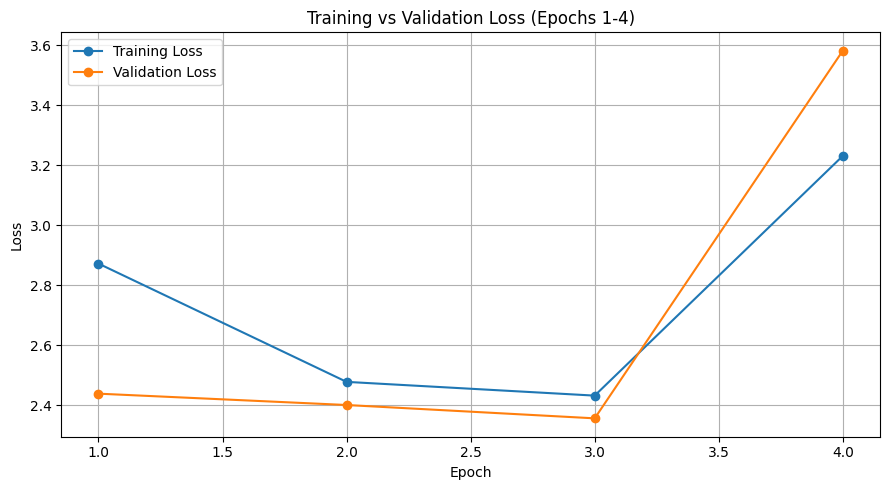

In [ ]:
plt.figure(figsize=(9,5))
if train_loss_plot:
    plt.plot(range(1, 1+len(train_loss_plot)), train_loss_plot, marker='o', label="Training Loss")
if eval_loss_plot:
    plt.plot(range(1, 1+len(eval_loss_plot)), eval_loss_plot, marker='o', label="Validation Loss")
plt.title("Training vs Validation Loss (Epochs 1-4)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("loss_curve_epochs1-4.png")
plt.show()

## Plot: Validation ROUGE-L

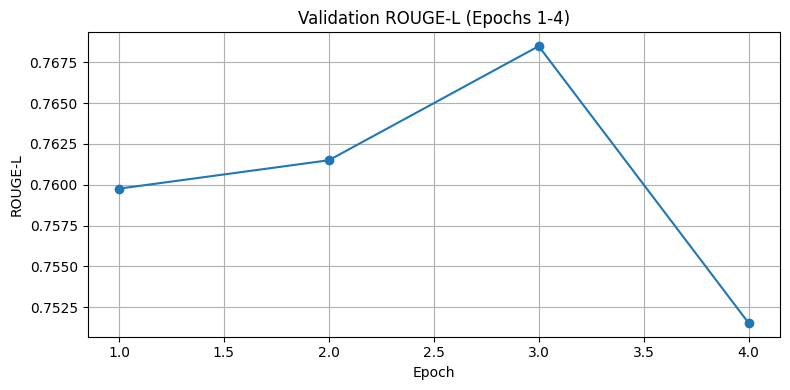

In [ ]:
if eval_rougeL_plot:
    plt.figure(figsize=(8,4))
    plt.plot(range(1, 1+len(eval_rougeL_plot)), eval_rougeL_plot, marker='o')
    plt.title("Validation ROUGE-L (Epochs 1-4)")
    plt.xlabel("Epoch"); plt.ylabel("ROUGE-L")
    plt.grid(True); plt.tight_layout()
    plt.savefig("rougeL_curve_epochs1-4.png")
    plt.show()

## Plot: Validation BERTScore-F1

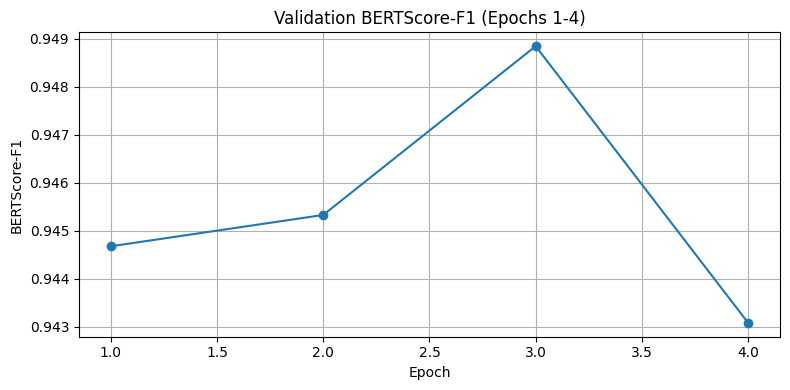

In [ ]:
if eval_bertscore_plot:
    plt.figure(figsize=(8,4))
    plt.plot(range(1, 1+len(eval_bertscore_plot)), eval_bertscore_plot, marker='o')
    plt.title("Validation BERTScore-F1 (Epochs 1-4)")
    plt.xlabel("Epoch"); plt.ylabel("BERTScore-F1")
    plt.grid(True); plt.tight_layout()
    plt.savefig("bertscore_curve_epochs1-4.png")
    plt.show()

## Generation Helpers & Sample Predictions

In [ ]:
def generate_batch(texts, strategy="greedy", temperature=1.0, top_k=None, top_p=None, num_beams=1):
    inputs = ["summarize: " + (t or "") for t in texts]
    enc = tokenizer(inputs, return_tensors="pt", padding=True, truncation=True, max_length=max_input_length).to(device)
    gen_kwargs = {"max_length": max_target_length}
    if strategy == "greedy":
        gen_kwargs.update({"num_beams": num_beams, "do_sample": False})
    else:
        gen_kwargs.update({"do_sample": True, "temperature": temperature})
        if top_k is not None:
            gen_kwargs["top_k"] = top_k
        if top_p is not None:
            gen_kwargs["top_p"] = top_p
    out = model.generate(**enc, **gen_kwargs)
    return tokenizer.batch_decode(out, skip_special_tokens=True, clean_up_tokenization_spaces=True)

# print first 10 in the exact block format you requested
print("\n" + "-"*80)
print("=== FIRST 10 TEST RESULTS (Formatted Output) ===")
print("-"*80)

sample_count = min(10, len(dataset["test"]))
rows = []
for i in range(sample_count):
    row = dataset["test"][i]
    gold = row["title"]
    desc = row["description"]
    gen = generate_batch([desc], strategy="greedy", num_beams=4)[0]
    print("-"*80)
    print(f"NEWS {i+1}")
    print(f"GOLD HEADLINE     : {gold}")
    print(f"GENERATED HEADLINE: {gen}")
    print(f"DESCRIPTION       : {desc[:400].strip()} ...")
    print("-"*80)
    rows.append({"idx": i+1, "category": row["label_name"], "gold": gold, "pred": gen, "description": desc})

df_out = pd.DataFrame(rows)
df_out.to_csv("t5_recommended_sample_predictions.csv", index=False)
print("Saved sample predictions to t5_recommended_sample_predictions.csv")


--------------------------------------------------------------------------------
=== FIRST 10 TEST RESULTS (Formatted Output) ===
--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
NEWS 1
GOLD HEADLINE     : Fears N pension talks Unions representing workers Turner Newall say 'disappointed talks
GENERATED HEADLINE: Fears N pension talks Unions representing workers Turner Newall say 'disappointed talks
DESCRIPTION       : Fears for T N pension after talks Unions representing workers at Turner Newall say they are 'disappointed' after talks with stricken parent firm Federal Mogul. ...
--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
NEWS 2
GOLD HEADLINE     : Race Second Private Team Sets Launch Date Human Spaceflight SPACE.com TORONTO
GENERATED HEADLINE: Race Second P

## Final Evaluation (Greedy Decoding)

In [ ]:
subset = dataset["test"].select(range(min(2000, len(dataset["test"]))))   # subset for faster eval
texts = subset["description"]
golds = subset["title"]

preds = []
bsz = 32
for i in range(0, len(texts), bsz):
    batch_texts = texts[i:i+bsz]
    batch_preds = generate_batch(batch_texts, strategy="greedy", num_beams=4)
    preds.extend(batch_preds)

preds_f, golds_f = safe_filter(preds, golds)
if preds_f:
    rouge_r = rouge.compute(predictions=preds_f, references=golds_f)
    bert_r  = bertscore.compute(predictions=preds_f, references=golds_f, lang="en", rescale_with_baseline=False)
    print("\nFINAL (subset) ROUGE-1: {:.4f}".format(float(rouge_r.get("rouge1", 0.0))))
    print("FINAL (subset) ROUGE-2: {:.4f}".format(float(rouge_r.get("rouge2", 0.0))))
    print("FINAL (subset) ROUGE-L: {:.4f}".format(float(rouge_r.get("rougeL", 0.0))))
    print("FINAL (subset) BERT-F1: {:.4f}".format(float(np.mean(bert_r["f1"]))))
else:
    print("No valid predictions (all empty) on subset evaluation.")

pd.DataFrame({"description": texts, "gold": golds, "pred": preds}).to_csv("t5_recommended_predictions_full_subset.csv", index=False)
print("Saved t5_recommended_predictions_full_subset.csv")


FINAL (subset) ROUGE-1: 0.7688
FINAL (subset) ROUGE-2: 0.7458
FINAL (subset) ROUGE-L: 0.7681
FINAL (subset) BERT-F1: 0.9468
Saved t5_recommended_predictions_full_subset.csv

## Decoding Strategy Comparison

In [ ]:
STRATEGIES = {
    "greedy": {"strategy": "greedy"},
    "temperature_0.8": {"strategy": "sample", "temperature": 0.8},
    "top_k_50": {"strategy": "sample", "top_k": 50, "temperature": 1.0},
    "top_p_0.9": {"strategy": "sample", "top_p": 0.9, "temperature": 1.0}
}

results_rows = []
label_names_local = label_names
rouge_matrix = np.zeros((len(label_names_local), len(STRATEGIES)))
bert_matrix  = np.zeros((len(label_names_local), len(STRATEGIES)))
strategy_names = list(STRATEGIES.keys())

# batch-evaluate strategies
for j, (sname, sparams) in enumerate(STRATEGIES.items()):
    print(f"\nEvaluating strategy: {sname}")
    preds_s = []
    golds_s = []
    labs_s = []
    for i in range(0, len(texts), bsz):
        batch_texts = texts[i:i+bsz]
        if sparams["strategy"] == "greedy":
            batch_preds = generate_batch(batch_texts, strategy="greedy", num_beams=4)
        else:
            batch_preds = generate_batch(
                batch_texts,
                strategy="sample",
                temperature=sparams.get("temperature", 1.0),
                top_k=sparams.get("top_k", None),
                top_p=sparams.get("top_p", None),
                num_beams=1
            )
        preds_s.extend(batch_preds)
        golds_s.extend(golds[i:i+len(batch_preds)])
        labs_s.extend(subset["label_name"][i:i+len(batch_preds)])

    preds_f, golds_f = safe_filter(preds_s, golds_s)
    if preds_f:
        r_overall = rouge.compute(predictions=preds_f, references=golds_f)
        b_overall = bertscore.compute(predictions=preds_f, references=golds_f, lang="en", rescale_with_baseline=False)
        b_overall_f1 = float(np.mean(b_overall["f1"]))
    else:
        r_overall = {"rouge1":0.0, "rouge2":0.0, "rougeL":0.0}
        b_overall_f1 = 0.0

    results_rows.append({
        "Strategy": sname,
        "ROUGE-1": float(r_overall.get("rouge1",0.0)),
        "ROUGE-2": float(r_overall.get("rouge2",0.0)),
        "ROUGE-L": float(r_overall.get("rougeL",0.0)),
        "BERT-F1": float(b_overall_f1)
    })

    # per-class metrics
    for ci, cat in enumerate(label_names_local):
        p_c = [p for p, lab in zip(preds_s, labs_s) if lab == cat]
        g_c = [g for g, lab in zip(golds_s, labs_s) if lab == cat]
        p_c_f, g_c_f = safe_filter(p_c, g_c)
        if p_c_f:
            r_c = rouge.compute(predictions=p_c_f, references=g_c_f)
            b_c = bertscore.compute(predictions=p_c_f, references=g_c_f, lang="en", rescale_with_baseline=False)
            r_val = float(r_c.get("rougeL", 0.0))
            b_val = float(np.mean(b_c["f1"]))
        else:
            r_val = 0.0; b_val = 0.0
        rouge_matrix[ci, j] = r_val * 100.0
        bert_matrix[ci, j] = b_val * 100.0

    print("Overall ROUGE-L: {:.4f} | BERT-F1: {:.4f}".format(float(r_overall.get("rougeL",0.0)), b_overall_f1))
    for cat in label_names_local:
        cnt = sum(1 for l in labs_s if l == cat)
        print(f"{cat:<10} N={cnt:<4}")

# Save strategy comparison CSV
df_strat = pd.DataFrame(results_rows)
df_strat.to_csv("strategy_comparison_optionA.csv", index=False)
print("Saved strategy_comparison_optionA.csv")

Evaluating strategy: greedy
Overall ROUGE-L: 0.7681 | BERT-F1: 0.9468
World      N=511 
Sports     N=526 
Business   N=449 
Sci/Tech   N=514 

Evaluating strategy: temperature_0.8
Overall ROUGE-L: 0.7598 | BERT-F1: 0.9480
World      N=511 
Sports     N=526 
Business   N=449 
Sci/Tech   N=514 

Evaluating strategy: top_k_50
Overall ROUGE-L: 0.7390 | BERT-F1: 0.9439
World      N=511 
Sports     N=526 
Business   N=449 
Sci/Tech   N=514 

Evaluating strategy: top_p_0.9
Overall ROUGE-L: 0.7631 | BERT-F1: 0.9501
World      N=511 
Sports     N=526 
Business   N=449 
Sci/Tech   N=514 
Saved strategy_comparison_optionA.csv

## Plot: Strategy Comparison

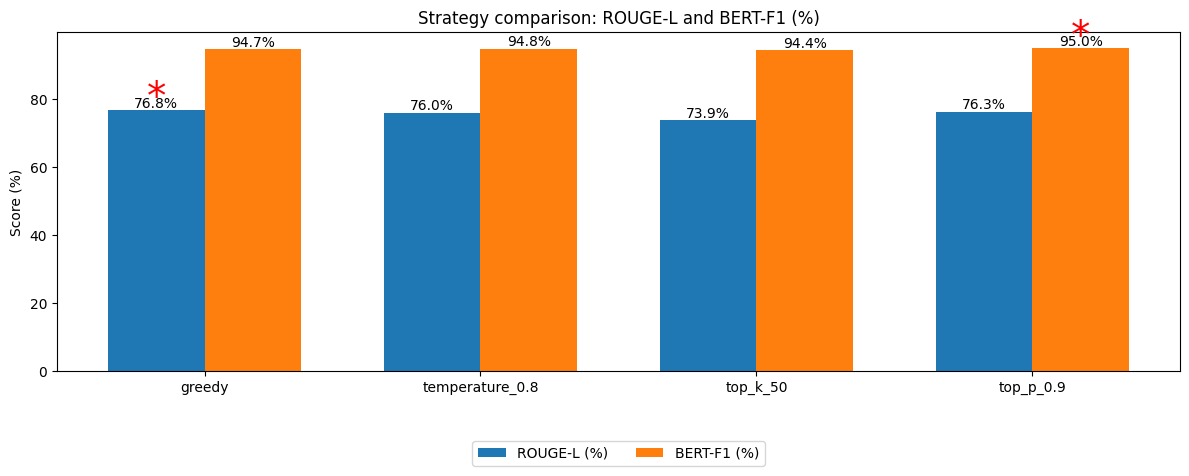

In [ ]:
df_plot = df_strat.copy()
df_plot["ROUGE-L%"] = df_plot["ROUGE-L"] * 100.0
df_plot["BERT-F1%"] = df_plot["BERT-F1"] * 100.0

strategies = df_plot["Strategy"].tolist()
rouge_vals = df_plot["ROUGE-L%"].tolist()
bert_vals  = df_plot["BERT-F1%"].tolist()

x = np.arange(len(strategies))
width = 0.35

plt.figure(figsize=(12, 5))
plt.bar(x - width/2, rouge_vals, width, label="ROUGE-L (%)")
plt.bar(x + width/2, bert_vals,  width, label="BERT-F1 (%)")

# value labels
for i in range(len(strategies)):
    plt.text(x[i] - width/2, rouge_vals[i] + 0.8, f"{rouge_vals[i]:.1f}%", ha="center")
    plt.text(x[i] + width/2, bert_vals[i] + 0.8, f"{bert_vals[i]:.1f}%", ha="center")

# asterisks for best ROUGE-L and best BERT-F1
best_idx_r = int(df_plot["ROUGE-L%"].idxmax())
best_idx_b = int(df_plot["BERT-F1%"].idxmax())
plt.text(x[best_idx_r] - width/2, rouge_vals[best_idx_r] + 3.5, "*", color="red", fontsize=28, ha="center", va="center")
plt.text(x[best_idx_b] + width/2, bert_vals[best_idx_b] + 3.5, "*", color="red", fontsize=28, ha="center", va="center")

plt.xticks(x, strategies)
plt.title("Strategy comparison: ROUGE-L and BERT-F1 (%)")
plt.ylabel("Score (%)")
plt.legend(loc="lower center", bbox_to_anchor=(0.5, -0.30), ncol=2)
plt.tight_layout()
plt.savefig("strategy_combined_bar_with_asterisk.png")
plt.show()

## Plot: Per-Strategy Scores

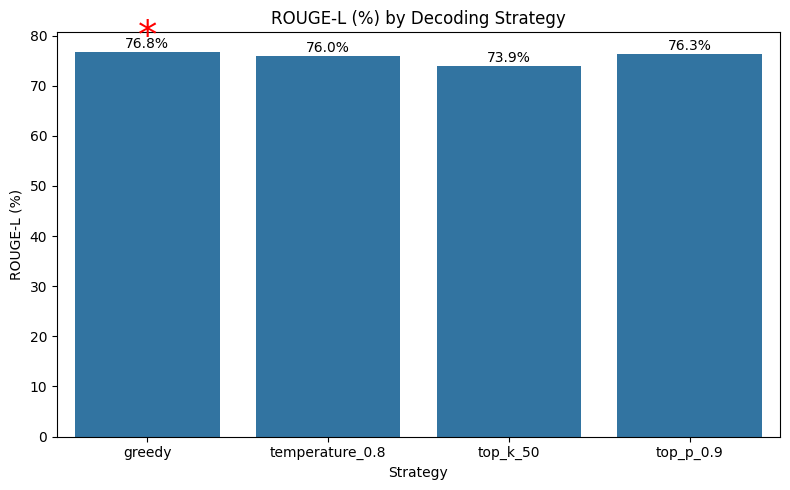

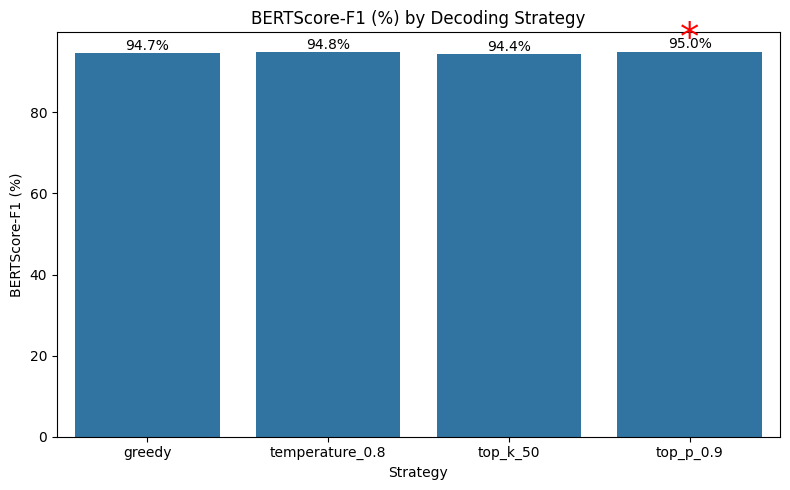

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=df_plot, x="Strategy", y="ROUGE-L%")
for i, v in enumerate(df_plot["ROUGE-L%"]):
    plt.text(i, v + 0.8, f"{v:.1f}%", ha='center')
# asterisk on best
best_idx = int(df_plot["ROUGE-L%"].idxmax())
plt.text(best_idx, df_plot.loc[best_idx,"ROUGE-L%"] + 3.0, "*", color="red", fontsize=28, ha="center", va="center")
plt.title("ROUGE-L (%) by Decoding Strategy"); plt.ylabel("ROUGE-L (%)")
plt.tight_layout(); plt.savefig("strategy_rougeL_bar.png"); plt.show()

plt.figure(figsize=(8,5))
sns.barplot(data=df_plot, x="Strategy", y="BERT-F1%")
for i, v in enumerate(df_plot["BERT-F1%"]):
    plt.text(i, v + 0.8, f"{v:.1f}%", ha='center')
best_idx = int(df_plot["BERT-F1%"].idxmax())
plt.text(best_idx, df_plot.loc[best_idx,"BERT-F1%"] + 3.0, "*", color="red", fontsize=28, ha="center", va="center")
plt.title("BERTScore-F1 (%) by Decoding Strategy"); plt.ylabel("BERTScore-F1 (%)")
plt.tight_layout(); plt.savefig("strategy_bertf1_bar.png"); plt.show()

## Plot: Per-Class Scores by Strategy

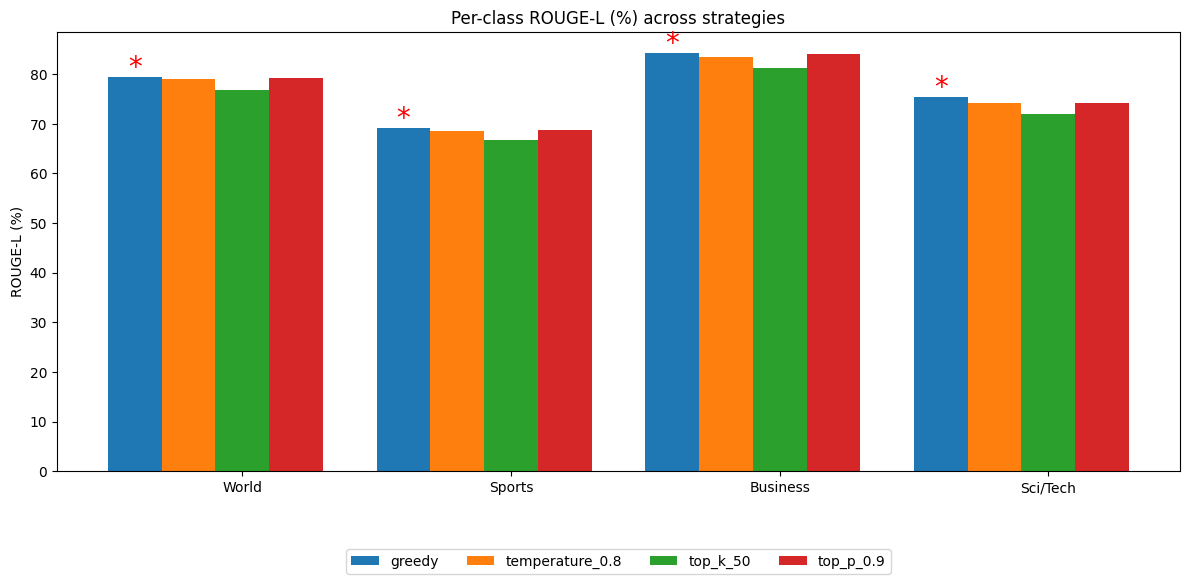

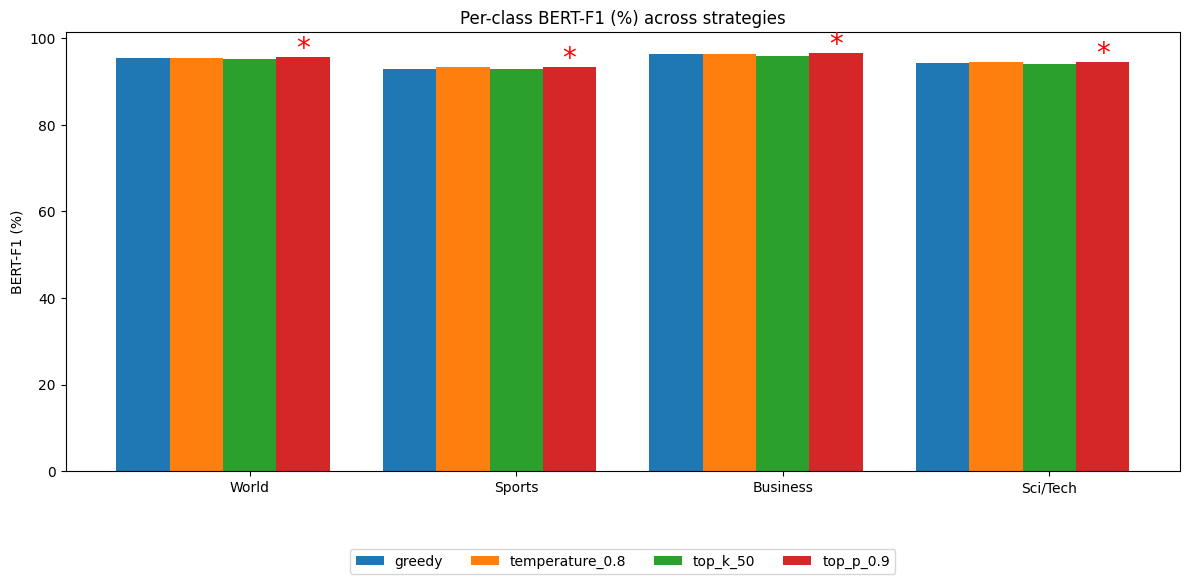

In [ ]:
classes = label_names_local
col_names = strategy_names  # columns correspond to strategies in same order

# Example: show per-class for greedy (col 0) — but we'll create a grouped per-class view across strategies
# Per-class grouped bars
plt.figure(figsize=(12,6))
n_strat = len(strategy_names)
x = np.arange(len(classes))
width = 0.8 / n_strat
for j in range(n_strat):
    plt.bar(x - 0.4 + j*width, rouge_matrix[:, j], width, label=strategy_names[j])
# place asterisk above the max across strategies for each class (ROUGE)
for i in range(len(classes)):
    max_j = int(np.argmax(rouge_matrix[i, :]))
    val = rouge_matrix[i, max_j]
    plt.text(x[i] - 0.4 + max_j*width, val + 1.8, "*", color="red", fontsize=20, ha="center", va="center")
plt.xticks(x, classes)
plt.title("Per-class ROUGE-L (%) across strategies")
plt.ylabel("ROUGE-L (%)")
plt.legend(loc="lower center", bbox_to_anchor=(0.5, -0.25), ncol=n_strat)
plt.tight_layout(); plt.savefig("per_class_rouge_grouped.png"); plt.show()

plt.figure(figsize=(12,6))
for j in range(n_strat):
    plt.bar(x - 0.4 + j*width, bert_matrix[:, j], width, label=strategy_names[j])
# asterisks for per-class best BERT
for i in range(len(classes)):
    max_j = int(np.argmax(bert_matrix[i, :]))
    val = bert_matrix[i, max_j]
    plt.text(x[i] - 0.4 + max_j*width, val + 1.8, "*", color="red", fontsize=20, ha="center", va="center")
plt.xticks(x, classes)
plt.title("Per-class BERT-F1 (%) across strategies")
plt.ylabel("BERT-F1 (%)")
plt.legend(loc="lower center", bbox_to_anchor=(0.5, -0.25), ncol=n_strat)
plt.tight_layout(); plt.savefig("per_class_bert_grouped.png"); plt.show()

## Plot: Per-Class Heatmaps

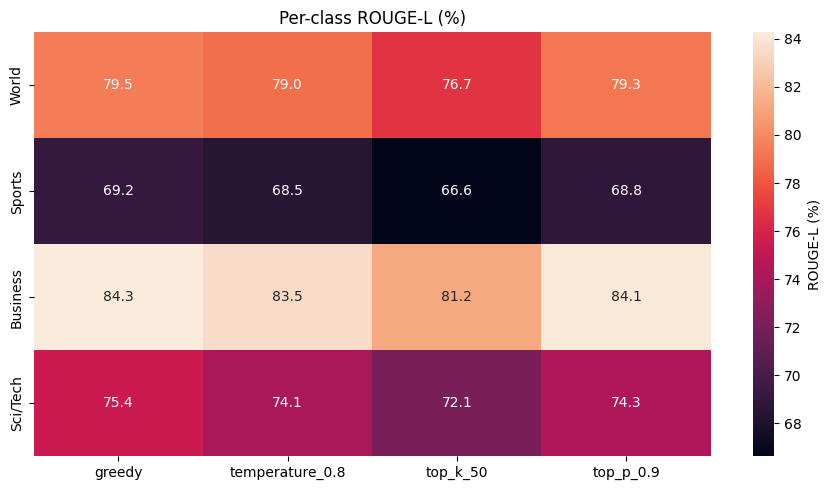

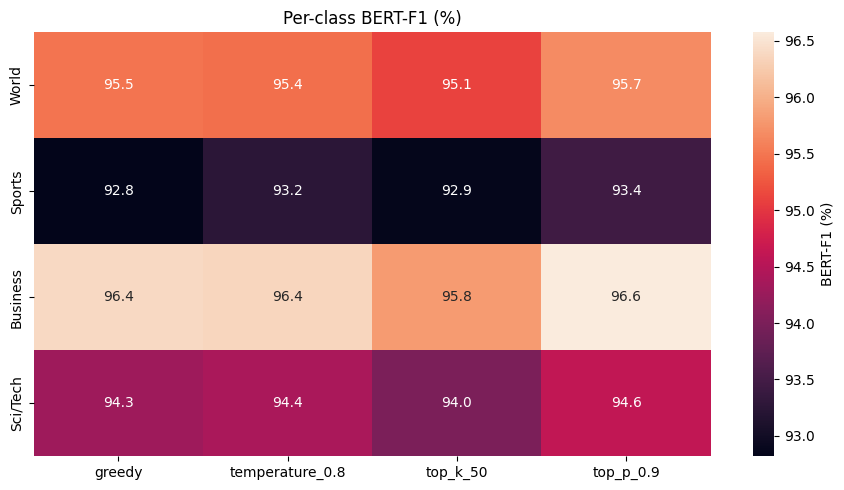

In [ ]:
plt.figure(figsize=(9,5))
sns.heatmap(rouge_matrix, annot=True, fmt=".1f", xticklabels=strategy_names, yticklabels=classes, cbar_kws={"label":"ROUGE-L (%)"})
plt.title("Per-class ROUGE-L (%)")
plt.tight_layout(); plt.savefig("per_class_rouge_heatmap.png"); plt.show()

plt.figure(figsize=(9,5))
sns.heatmap(bert_matrix, annot=True, fmt=".1f", xticklabels=strategy_names, yticklabels=classes, cbar_kws={"label":"BERT-F1 (%)"})
plt.title("Per-class BERT-F1 (%)")
plt.tight_layout(); plt.savefig("per_class_bert_heatmap.png"); plt.show()

## Save Evaluation Artifacts

In [ ]:
pd.DataFrame(rouge_matrix, index=classes, columns=strategy_names).to_csv("rouge_per_class_matrix_percent.csv")
pd.DataFrame(bert_matrix, index=classes, columns=strategy_names).to_csv("bert_per_class_matrix_percent.csv")
df_out.to_csv("t5_recommended_sample_predictions.csv", index=False)
df_strat.to_csv("strategy_comparison_optionA.csv", index=False)

eval_report = {
    "final_rouge": rouge_r if 'rouge_r' in globals() else {},
    "final_bert_f1": float(np.mean(bert_r["f1"])) if ('bert_r' in globals() and bert_r and "f1" in bert_r) else None,
    "strategy_table": df_strat.to_dict(orient="records")
}
with open("t5_recommended_eval_report.json", "w") as f:
    json.dump(eval_report, f, indent=2)
print("Saved evaluation artifacts and report.")

print("\nAll done — plot files saved. Example files:")
print("- loss_curve_epochs1-4.png")
print("- rougeL_curve_epochs1-4.png")
print("- bertscore_curve_epochs1-4.png")
print("- strategy_combined_bar_with_asterisk.png")
print("- strategy_rougeL_bar.png")
print("- strategy_bertf1_bar.png")
print("- per_class_rouge_grouped.png")
print("- per_class_bert_grouped.png")
print("- per_class_rouge_heatmap.png")
print("- per_class_bert_heatmap.png")